In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [14]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [15]:
# load dataset path
original_dir = "/content/drive/MyDrive/AIassesment/part2/flowers"
base_dir     = "/content/split_data"
train_dir    = os.path.join(base_dir, "train")
val_dir      = os.path.join(base_dir, "val")
test_dir     = os.path.join(base_dir, "test")

#
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

In [16]:
import os

if not os.path.exists(original_dir):
    print(f"Error: The directory specified for the dataset, '{original_dir}', was not found.")
    raise FileNotFoundError(f"Dataset directory not found: {original_dir}")

classes = os.listdir(original_dir)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['dandelion', 'rose', 'tulip', 'sunflower', 'daisy']
Number of classes: 5


In [17]:
#Total number of images

total_images = 0
class_counts = {}

for cls in classes:
    total_images += len(os.listdir(os.path.join(original_dir, cls)))
    class_path = os.path.join(original_dir, cls)
    class_counts[cls] = len(os.listdir(class_path))


print("Total images in dataset:", total_images)
print(class_counts)

Total images in dataset: 4317
{'dandelion': 1052, 'rose': 784, 'tulip': 984, 'sunflower': 733, 'daisy': 764}


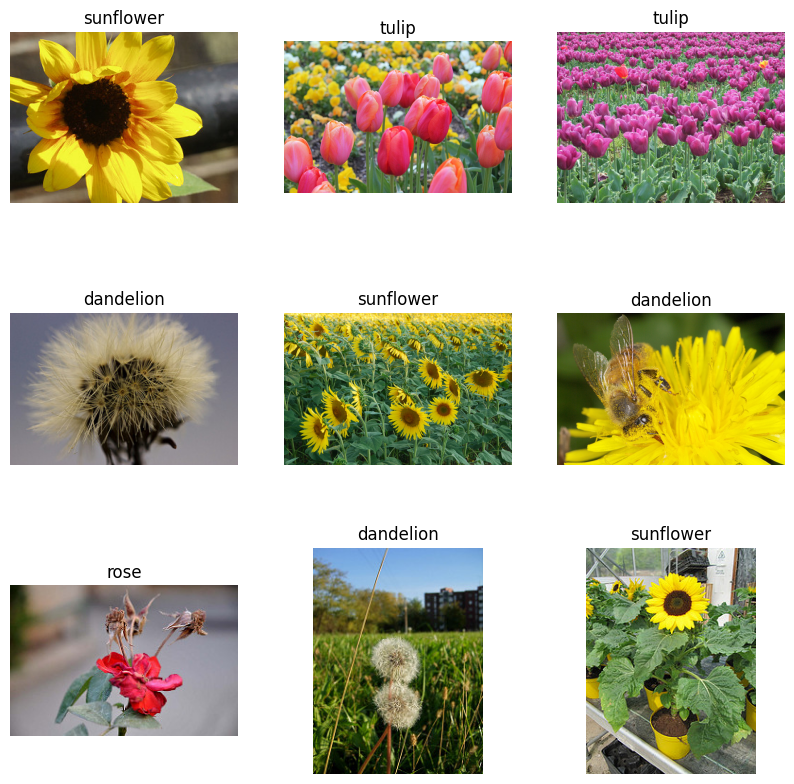

In [18]:
# Quick visualization - making sure the data actually looks decent
plt.figure(figsize=(10,10))

for i in range(9):
    cls = random.choice(classes)
    img_path = os.path.join(original_dir, cls, random.choice(os.listdir(os.path.join(original_dir, cls))))

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

##Check for Courrupted Images

In [19]:
#check for the corrupted images
corrupted_images = []  # List to store corrupted image paths

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print(f"\n  Corrupted Images Found: {len(corrupted_images)}")
    for img in corrupted_images:
        print(f"   Removing: {img}")
        os.remove(img)
    print(" Corrupted images removed.")
else:
    print("\n No corrupted images found.")


 No corrupted images found.


##Evaluates the  Class Balance
A balanced dataset prevents any single category from overshadowing the others. When certain classes contain a disproportionately high number of images, the model risks developing a bias, leading it to favor those overrepresented groups during predictions.

In [20]:
# Dictionary to store class counts
class_counts = {}

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

# Print Class Distribution
total = sum(class_counts.values())

print("\nClass Distribution:")
print("=" * 55)
print(f"{'Class Name':<20} {'Image Count':>12} {'Percentage':>12}")
print("=" * 55)
for class_name, count in class_counts.items():
    pct = (count / total) * 100
    print(f"{class_name:<20} {count:>12} {pct:>11.1f}%")
print("=" * 55)
print(f"{'TOTAL':<20} {total:>12} {'100.0%':>12}")


Class Distribution:
Class Name            Image Count   Percentage
dandelion                    1052        24.4%
rose                          784        18.2%
tulip                         984        22.8%
sunflower                     733        17.0%
daisy                         764        17.7%
TOTAL                        4317       100.0%


##Visualize Class Distribution

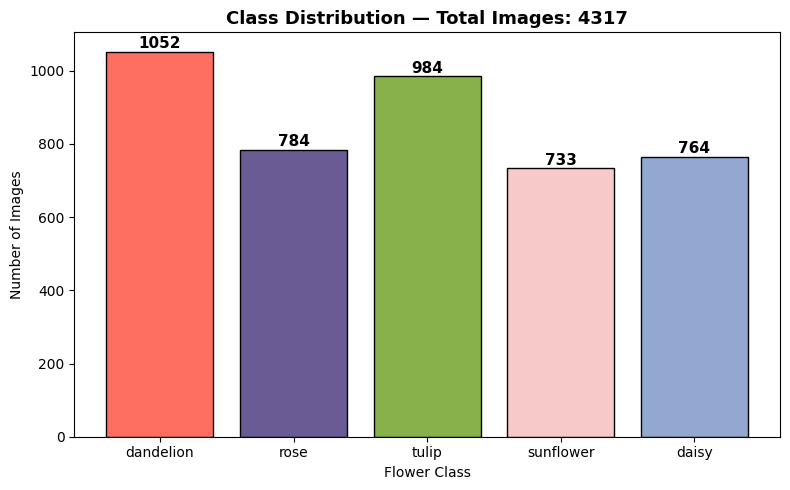

In [21]:
new_colors_bar = ["#FF6F61", "#6B5B95", "#88B04B", "#F7CAC9", "#92A8D1"]
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=new_colors_bar, edgecolor='black')

for bar, count in zip(bars, class_counts.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(count), ha='center', fontsize=11, fontweight='bold'
    )

plt.title(f"Class Distribution — Total Images: {total}", fontsize=13, fontweight='bold')
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

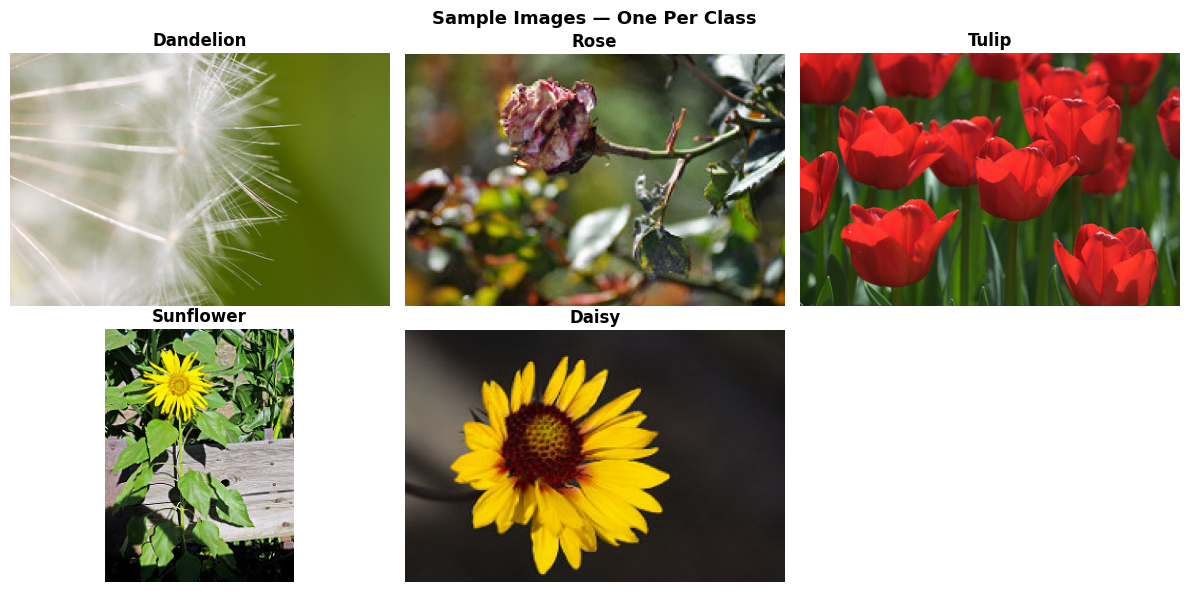

In [22]:
selected_images = []  # Stores image paths
selected_labels = []  # Stores corresponding class names

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Plot in grid
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i].capitalize(), fontweight='bold')
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.suptitle("Sample Images — One Per Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Split Dataset - Trian, Validation and Test

In [23]:
import os
import shutil
import random

In [24]:
# ── Only split if not already done ──
if os.path.exists(base_dir) and len(os.listdir(base_dir)) > 0:
    print(" Split already exists — skipping to avoid duplicates.")
else:
    print(" Creating split folders...")

    for folder in [train_dir, val_dir, test_dir]:
        os.makedirs(folder, exist_ok=True)

    for cls in classes:
        cls_path = os.path.join(original_dir, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            random.shuffle(images)

            total_cls  = len(images)
            train_end  = int(0.70 * total_cls)
            val_end    = int(0.85 * total_cls)

            for i, img in enumerate(images):
                src = os.path.join(cls_path, img)
                if i < train_end:
                    dst_dir = os.path.join(train_dir, cls)
                elif i < val_end:
                    dst_dir = os.path.join(val_dir, cls)
                else:
                    dst_dir = os.path.join(test_dir, cls)

                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy(src, os.path.join(dst_dir, img))

    print(" Dataset split complete!")

# ── Print split summary ──
print("\nSplit Summary:")
print("=" * 40)
print(f"{'Split':<15} {'Images':>10} {'%':>8}")
print("=" * 40)
for split_name, split_dir in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
    count = sum(
        len(os.listdir(os.path.join(split_dir, cls)))
        for cls in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, cls))
    )
    print(f"{split_name:<15} {count:>10}  {count/total*100:>6.1f}%")
print("=" * 40)

 Creating split folders...
 Dataset split complete!

Split Summary:
Split               Images        %
Train                 3019    69.9%
Validation             649    15.0%
Test                   649    15.0%


##Check Class Imbalance After Split

In [25]:
# Updates class_names from train_dir after split
class_names = sorted(os.listdir(train_dir))

# Count per class in train
class_counts_train = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts_train[class_name] = len(images)

train_total = sum(class_counts_train.values())

print("\nClass Distribution (Train Set):")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts_train.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution (Train Set):
Class Name               Valid Image Count
daisy                                534
dandelion                            736
rose                                 548
sunflower                            513
tulip                                688


##Data Augmentation

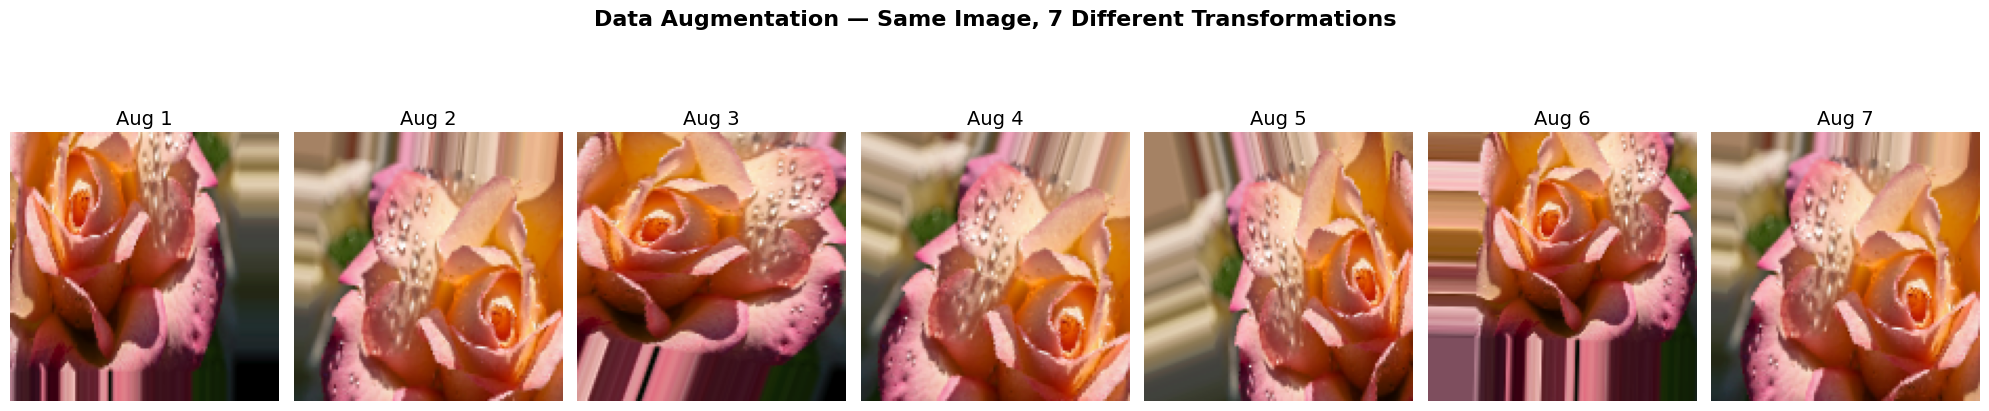

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=30,       # Rotate images by up to 30 degrees
    width_shift_range=0.2,   # Shift width by 20%
    height_shift_range=0.2,  # Shift height by 20%
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Zoom in/out by 20%
    horizontal_flip=True,    # Flip images horizontally
    fill_mode='nearest'      # Fill in missing pixels
)

# Load one sample image from train/rose
rose_dir        = os.path.join(train_dir, "rose")
sample_img_name = random.choice(os.listdir(rose_dir))
sample_img_path = os.path.join(rose_dir, sample_img_name)

img = image.load_img(sample_img_path, target_size=IMG_SIZE)
x   = image.img_to_array(img)
x   = np.expand_dims(x, axis=0)

# Generate and visualize 7 augmented images
aug_iter = datagen.flow(x, batch_size=1)

fig, axes = plt.subplots(1, 7, figsize=(20, 5))
fig.suptitle("Data Augmentation — Same Image, 7 Different Transformations",
             fontsize=16, fontweight='bold')

for i in range(7):
    batch = next(aug_iter)
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].set_title(f"Aug {i+1}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


##Create ImageDataGenerator for Training

In [27]:
# ── Training Generator: Augmentation + Normalization ──
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Val & Test Generators: Normalization ONLY ──
val_datagen  = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices : {train_generator.class_indices}")
print(f"   Train batches : {len(train_generator)}")
print(f"   Val   batches : {len(val_generator)}")
print(f"   Test  batches : {len(test_generator)}")

Found 3019 images belonging to 5 classes.
Found 649 images belonging to 5 classes.
Found 649 images belonging to 5 classes.

Class indices : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
   Train batches : 95
   Val   batches : 21
   Test  batches : 21


#Build the Baseline CNN Model

The baseline architecture consists of three convolutional layers, each paired with a max-pooling operation to extract spatial features efficiently. This feature extraction stage is followed by three fully connected (dense) layers to interpret the data, culminating in a five-class output layer utilizing a softmax activation function. Throughout the network's hidden layers, the ReLU activation function is employed to introduce non-linearity and facilitate effective learning.
|

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation, Dropout

NUM_CLASSES = len(class_names)

#  Baseline CNN Model
baseline_model = Sequential([

    #  Convolutional Block 1
    # 32 filters, 3x3 kernel, ReLU activation
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    # Convolutional Block 2
    # 64 filters — more filters to learn more complex features
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    #Convolutional Block 3
    # 128 filters — deeper features
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    #Flatten
    # Convert 3D feature maps to 1D vector
    Flatten(),

    # ── Fully Connected Layers ──
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),

    # ── Output Layer
    Dense(NUM_CLASSES, activation='softmax')
])

print(" Baseline model built successfully!")

 Baseline model built successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
#Model Summary

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

##Compiling the Baseline Model

In [30]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully!")

 Model compiled successfully!


##Train the Model

###We use the Earlystopping to prent from the overfitting and saves training time.

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if val_loss does not improve for 5 consecutive epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

import time
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

baseline_training_time = time.time() - start_time
print(f"\nTraining time: {baseline_training_time:.2f} seconds")

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 32s 264ms/step - accuracy: 0.4008 - loss: 1.3431 - val_accuracy: 0.5254 - val_loss: 1.1517
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.5237 - loss: 1.1306 - val_accuracy: 0.5701 - val_loss: 1.0984
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.5879 - loss: 1.0426 - val_accuracy: 0.6364 - val_loss: 0.9940
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 198ms/step - accuracy: 0.6217 - loss: 0.9565 - val_accuracy: 0.6348 - val_loss: 0.9405
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.6549 - loss: 0.8966 - val_accuracy: 0.6302 - val_loss: 0.9029
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 207ms/step - accuracy: 0.6857 - loss: 0.8357 - val_accuracy: 0.6687 - val_loss: 0.9082
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.6664 - loss: 0.8576 - val_accuracy: 0.6795 - val_loss: 0.8307
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 195ms/step - accuracy: 0.6823 - loss: 0.8119 - val_accu

##Plot Traiing vs Validation Loss and Accuracy

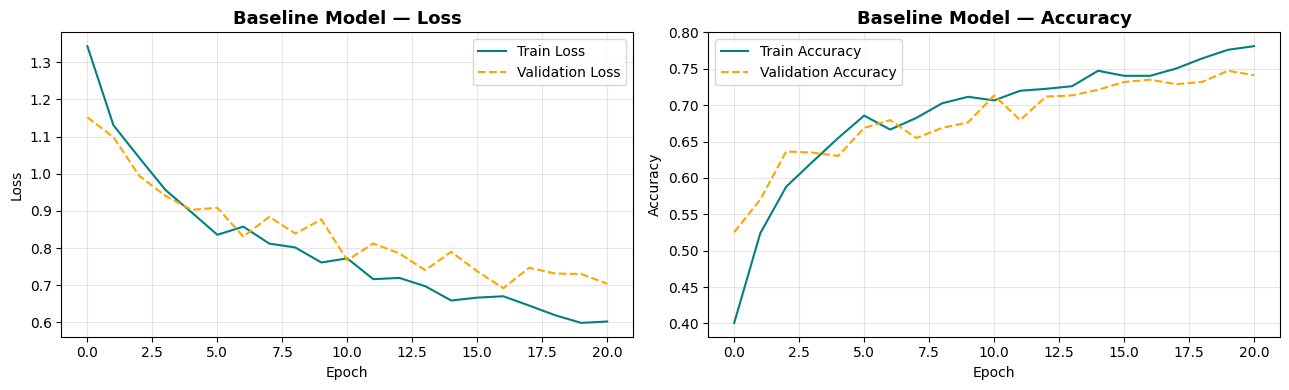

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss ──
axes[0].plot(baseline_history.history['loss'],     label='Train Loss',      color='teal')
axes[0].plot(baseline_history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0].set_title('Baseline Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──
axes[1].plot(baseline_history.history['accuracy'],     label='Train Accuracy',      color='teal')
axes[1].plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
axes[1].set_title('Baseline Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

##Evaluate the Model on Test Set

In [33]:
test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print("\n" + "=" * 40)
print(f"  Baseline Model — Test Results")
print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 40)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7519 - loss: 0.6262

  Baseline Model — Test Results
  Test Loss     : 0.6262
  Test Accuracy : 75.19%


##Classification Report

In [34]:
from sklearn.metrics import classification_report

# Get true labels and predictions
test_generator.reset()
predictions    = baseline_model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = test_generator.classes
class_names      = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print("=" * 60)
print(classification_report(true_labels, predicted_labels,
                             target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step

Classification Report:
              precision    recall  f1-score   support

       daisy       0.72      0.83      0.77       115
   dandelion       0.82      0.79      0.80       158
        rose       0.66      0.64      0.65       118
   sunflower       0.75      0.89      0.81       110
       tulip       0.80      0.63      0.70       148

    accuracy                           0.75       649
   macro avg       0.75      0.76      0.75       649
weighted avg       0.76      0.75      0.75       649



##Confusion Matrix

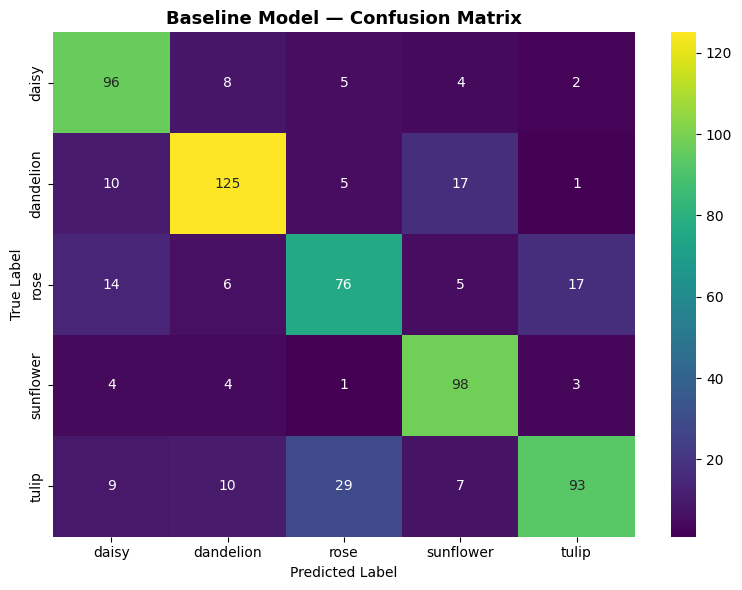

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', # colorsmap
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline Model — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

##Intference on Sample Images

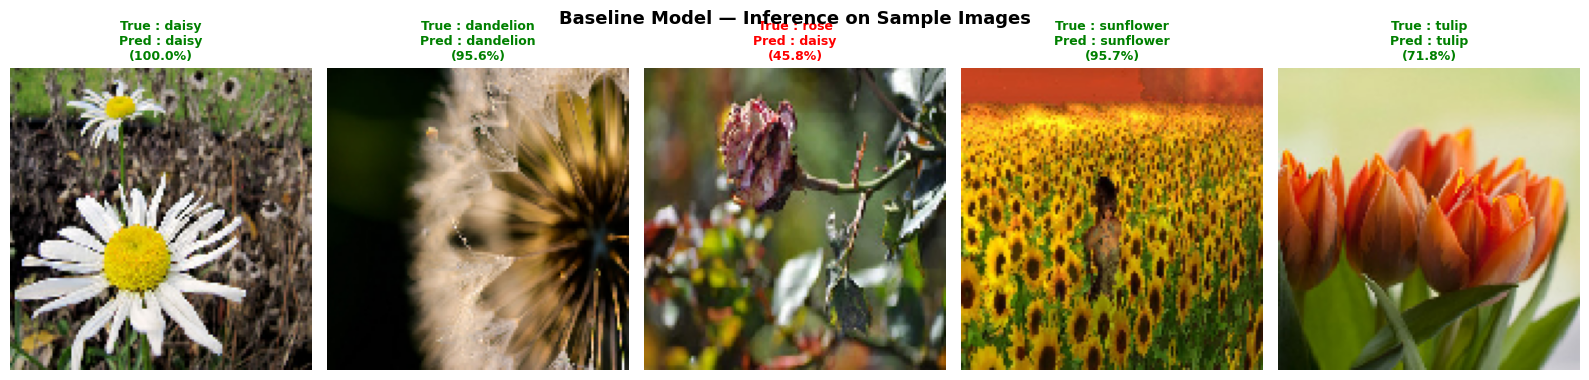


Green title = Correct prediction
   Red title   = Wrong prediction


In [36]:
import random
from tensorflow.keras.preprocessing import image as keras_image

# Pick 5 random images from test set
sample_images = []
sample_labels = []

for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    images     = os.listdir(class_path)
    img_name   = random.choice(images)
    sample_images.append(os.path.join(class_path, img_name))
    sample_labels.append(class_name)

# Plot predictions
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Baseline Model — Inference on Sample Images",
             fontsize=13, fontweight='bold')

for i, (img_path, true_label) in enumerate(zip(sample_images, sample_labels)):
    # Load and preprocess
    img      = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_arr  = keras_image.img_to_array(img) / 255.0
    img_arr  = np.expand_dims(img_arr, axis=0)

    # Predict
    pred        = baseline_model.predict(img_arr, verbose=0)
    pred_label  = class_names[np.argmax(pred)]
    confidence  = np.max(pred) * 100

    # Plot
    axes[i].imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    axes[i].axis('off')

    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(
        f"True : {true_label}\nPred : {pred_label}\n({confidence:.1f}%)",
        fontsize=9, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("baseline_inference.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGreen title = Correct prediction")
print("   Red title   = Wrong prediction")

##Save the Baseline CNN model

In [37]:
baseline_model.save("baseline_model.h5")
print("Baseline model saved as baseline_model.h5")

Baseline model saved as baseline_model.h5


#Build the Deeper CNN Model

Compared to the baseline (3 conv layers), this model has **6 convolutional layers** — double the depth.

Two new techniques are added:

**BatchNormalization:**
- Normalizes the output of each layer during training
- Helps the model train faster and more stably
- Reduces sensitivity to weight initialization

**Dropout:**
- Randomly switches off a fraction of neurons during training
- Prevents the model from memorizing training data (overfitting)
- `Dropout(0.25)` = 25% of neurons are switched off per step

In [38]:
def build_deeper_model(optimizer):
    """
    Builds and compiles the deeper CNN model.
    optimizer: pass 'adam' or SGD() object
    """
    model = Sequential([

        # ── Conv Block 1 ── (32 filters)
        Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 2 ── (64 filters)
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 3 ── (128 filters)
        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 4 ── (256 filters)
        Conv2D(256, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 5 ── (512 filters)
        Conv2D(512, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # ── Conv Block 6 ── (512 filters)
        Conv2D(512, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.2),

        # ── Flatten ──
        Flatten(),

        # ── Fully Connected Layers ──
        Dense(400),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(200),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        Dense(100),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),

        # ── Output Layer ──
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("build_deeper_model() function defined.")

build_deeper_model() function defined.


##Compililation of the Model


summary of the model


In [39]:
# Print summary using Adam (architecture is same regardless of optimizer)
temp_model = build_deeper_model('adam')
temp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,315,205 (27.91 MB)

 Trainable params: 7,310,797 (27.89 MB)

 Non-trainable params: 4,408 (17.22 KB)

##Training the Model

In [40]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import time

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

# Build with Adam
model_adam = build_deeper_model(optimizer=Adam(learning_rate=0.0005))

print("Training Deeper Model with ADAM...")
start_adam = time.time()

history_adam = model_adam.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_adam = time.time() - start_adam
print(f"\n Adam Training Time: {time_adam:.2f} seconds")

Training Deeper Model with ADAM...
Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 55s 365ms/step - accuracy: 0.3716 - loss: 1.5905 - val_accuracy: 0.2435 - val_loss: 3.1219
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.4535 - loss: 1.3127 - val_accuracy: 0.2435 - val_loss: 5.7459
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step - accuracy: 0.5118 - loss: 1.2130 - val_accuracy: 0.2435 - val_loss: 5.7164
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accuracy: 0.5379 - loss: 1.1360 - val_accuracy: 0.2435 - val_loss: 5.4326
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - accuracy: 0.5707 - loss: 1.0882 - val_accuracy: 0.2465 - val_loss: 4.3290
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.5856 - loss: 1.0509 - val_accuracy: 0.2650 - val_loss: 3.0221
Epoch 7/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.6158 - loss: 0.9952 - val_accuracy: 0.4361 - val_loss: 1.7822
Epoch 8/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accurac

##Adam Plot Trainign and the validaition Loss and Accuracy

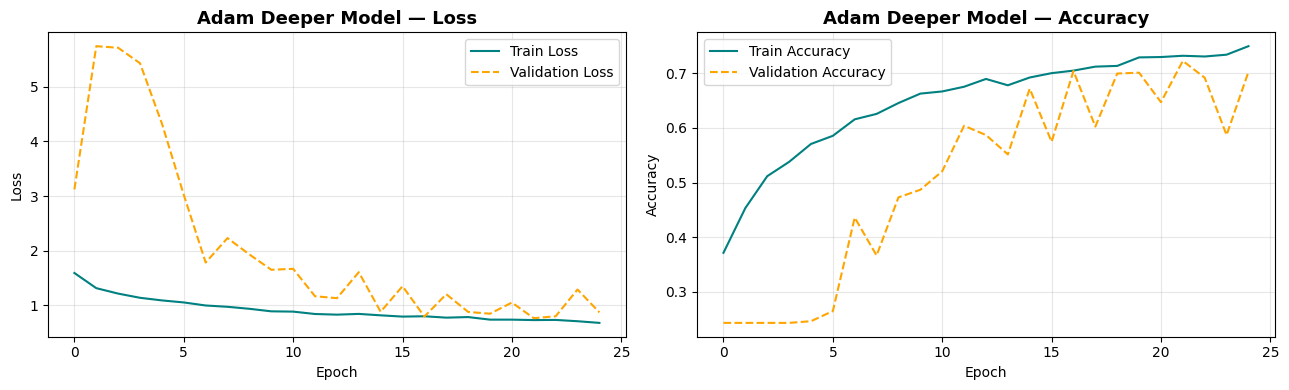

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history_adam.history['loss'],     label='Train Loss',      color='teal')
axes[0].plot(history_adam.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0].set_title('Adam Deeper Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_adam.history['accuracy'],     label='Train Accuracy',      color='teal')
axes[1].plot(history_adam.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
axes[1].set_title('Adam Deeper Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("deeper_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()



```
# This is formatted as code
```

#Training the Deeper Model with SGD Optimizer

In [42]:
from tensorflow.keras.optimizers import SGD

# Build with SG
model_sgd = build_deeper_model(
    optimizer=SGD(learning_rate=0.0005, momentum=0.9)
)

print("Training Deeper Model with SGD...")
start_sgd = time.time()

history_sgd = model_sgd.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_sgd = time.time() - start_sgd
print(f"\n SGD Training Time: {time_sgd:.2f} seconds")

Training Deeper Model with SGD...
Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 46s 333ms/step - accuracy: 0.2809 - loss: 1.7556 - val_accuracy: 0.2435 - val_loss: 2.0546
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.3736 - loss: 1.5288 - val_accuracy: 0.2435 - val_loss: 2.9571
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.4197 - loss: 1.4129 - val_accuracy: 0.2435 - val_loss: 3.3524
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.4525 - loss: 1.3556 - val_accuracy: 0.2450 - val_loss: 2.8879
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.4515 - loss: 1.3333 - val_accuracy: 0.2573 - val_loss: 2.6513
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.4737 - loss: 1.2796 - val_accuracy: 0.2773 - val_loss: 2.2733

 SGD Training Time: 146.52 seconds


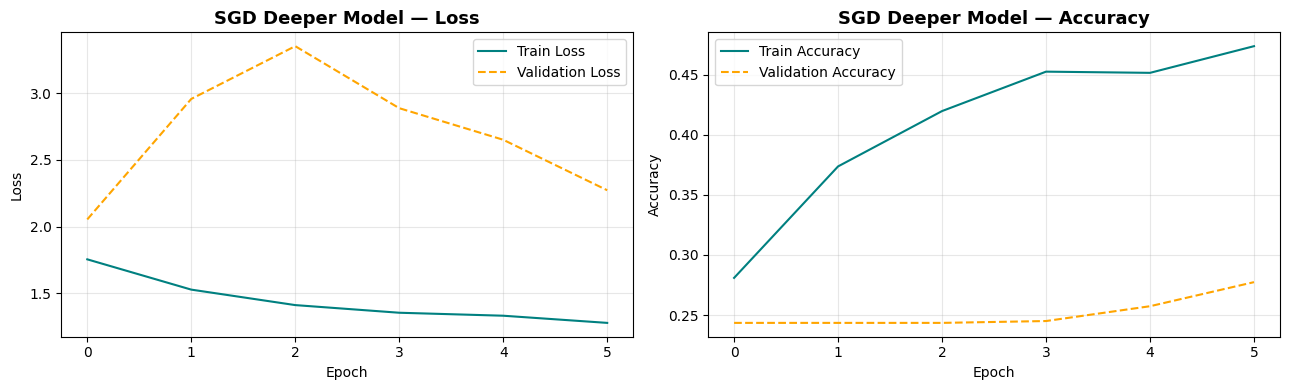

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history_sgd.history['loss'],     label='Train Loss',      color='teal')
axes[0].plot(history_sgd.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0].set_title('SGD Deeper Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_sgd.history['accuracy'],     label='Train Accuracy',      color='teal')
axes[1].plot(history_sgd.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
axes[1].set_title('SGD Deeper Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("deeper_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

##Compare Performance of Adam vs SGD - Training Curves

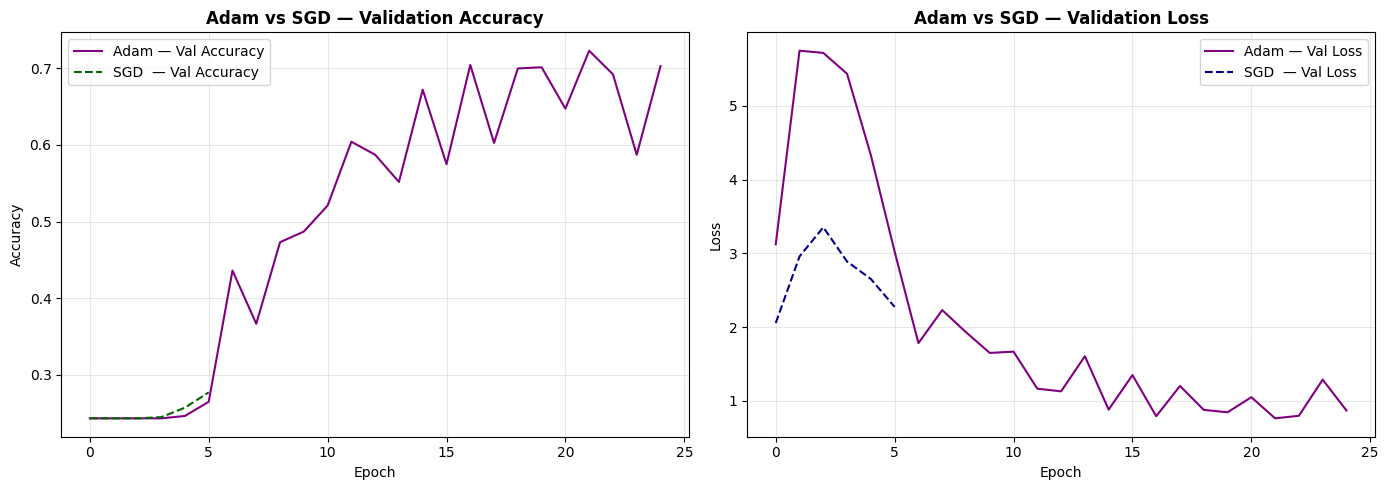

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(history_adam.history['val_accuracy'],
             label='Adam — Val Accuracy', color='purple') # colors
axes[0].plot(history_sgd.history['val_accuracy'],
             label='SGD  — Val Accuracy', color='darkgreen', linestyle='--') # colors
axes[0].set_title('Adam vs SGD — Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(history_adam.history['val_loss'],
             label='Adam — Val Loss', color='purple') # colors
axes[1].plot(history_sgd.history['val_loss'],
             label='SGD  — Val Loss', color='darkblue', linestyle='--') # colors
axes[1].set_title('Adam vs SGD — Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("adam_vs_sgd.png", dpi=150, bbox_inches='tight')
plt.show()

SGD's fixed learning rate led to fluctuating validation loss and early termination by EarlyStopping. Adam, with its adaptive learning rate, showed more stable convergence, trained longer, and achieved better results.

##Evaluate both optimizer on Test Set

In [45]:


loss_adam, acc_adam = model_adam.evaluate(test_generator, verbose=0)
loss_sgd,  acc_sgd  = model_sgd.evaluate(test_generator,  verbose=0)

print("=" * 50)
print(f"{'Metric':<20} {'Adam':>12} {'SGD':>12}")
print("=" * 50)
print(f"{'Test Accuracy':<20} {acc_adam*100:>11.2f}% {acc_sgd*100:>11.2f}%")
print(f"{'Test Loss':<20} {loss_adam:>12.4f} {loss_sgd:>12.4f}")
print(f"{'Training Time (s)':<20} {time_adam:>12.2f} {time_sgd:>12.2f}")
print("=" * 50)

Metric                       Adam          SGD
Test Accuracy              73.65%       24.35%
Test Loss                  0.6748       2.0546
Training Time (s)          574.43       146.52


##Comparision between Baseline vs Deeper Model(Adam)

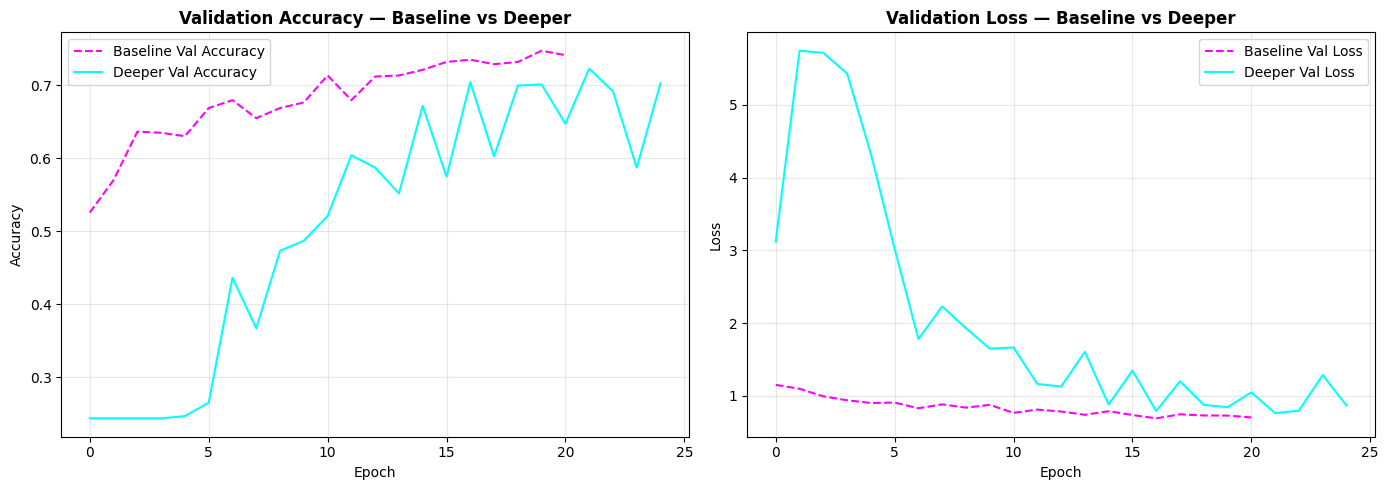

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Comparison ──
axes[0].plot(baseline_history.history['val_accuracy'],
             label='Baseline Val Accuracy', color='magenta', linestyle='--') # colors
axes[0].plot(history_adam.history['val_accuracy'],
             label='Deeper Val Accuracy',   color='cyan') # colors
axes[0].set_title('Validation Accuracy — Baseline vs Deeper', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss Comparison ──
axes[1].plot(baseline_history.history['val_loss'],
             label='Baseline Val Loss', color='magenta', linestyle='--') # colors
axes[1].plot(history_adam.history['val_loss'],
             label='Deeper Val Loss',   color='cyan') # colors
axes[1].set_title('Validation Loss — Baseline vs Deeper', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_vs_deeper.png", dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# ── Get baseline results (from Stage 2) ──
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator, verbose=0)
loss_adam,   acc_adam   = model_adam.evaluate(test_generator,   verbose=0)

print("=" * 55)
print(f"{'Metric':<25} {'Baseline':>12} {'Deeper':>12}")
print("=" * 55)
print(f"{'Test Accuracy':<25} {baseline_test_acc*100:>11.2f}% {acc_adam*100:>11.2f}%")
print(f"{'Test Loss':<25} {baseline_test_loss:>12.4f} {loss_adam:>12.4f}")
print(f"{'Training Time (s)':<25} {baseline_training_time:>12.2f} {time_adam:>12.2f}")



Metric                        Baseline       Deeper
Test Accuracy                   75.19%       73.65%
Test Loss                       0.6262       0.6748
Training Time (s)               414.83       574.43


#Ablation Study - Remove Dropout

In [48]:
# ── Model WITHOUT Dropout ──
model_no_dropout = Sequential([

    Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Flatten(),

    Dense(400),
    BatchNormalization(),
    Activation('relu'),

    Dense(200),
    BatchNormalization(),
    Activation('relu'),

    Dense(100),
    BatchNormalization(),
    Activation('relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

#Compile the model

model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model WITHOUT Dropout...")
start_ablation = time.time()

history_no_dropout = model_no_dropout.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_ablation = time.time() - start_ablation
print(f"\nAblation Training Time: {time_ablation:.2f} seconds")

Training model WITHOUT Dropout...
Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 285ms/step - accuracy: 0.4896 - loss: 1.2309 - val_accuracy: 0.2435 - val_loss: 4.0457
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.5793 - loss: 1.0349 - val_accuracy: 0.2604 - val_loss: 3.0800
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.6181 - loss: 0.9596 - val_accuracy: 0.3590 - val_loss: 2.3436
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 205ms/step - accuracy: 0.6406 - loss: 0.8979 - val_accuracy: 0.5408 - val_loss: 1.4023
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.6734 - loss: 0.8659 - val_accuracy: 0.5763 - val_loss: 1.0729
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.6890 - loss: 0.8210 - val_accuracy: 0.6810 - val_loss: 0.8647

Ablation Training Time: 138.62 seconds


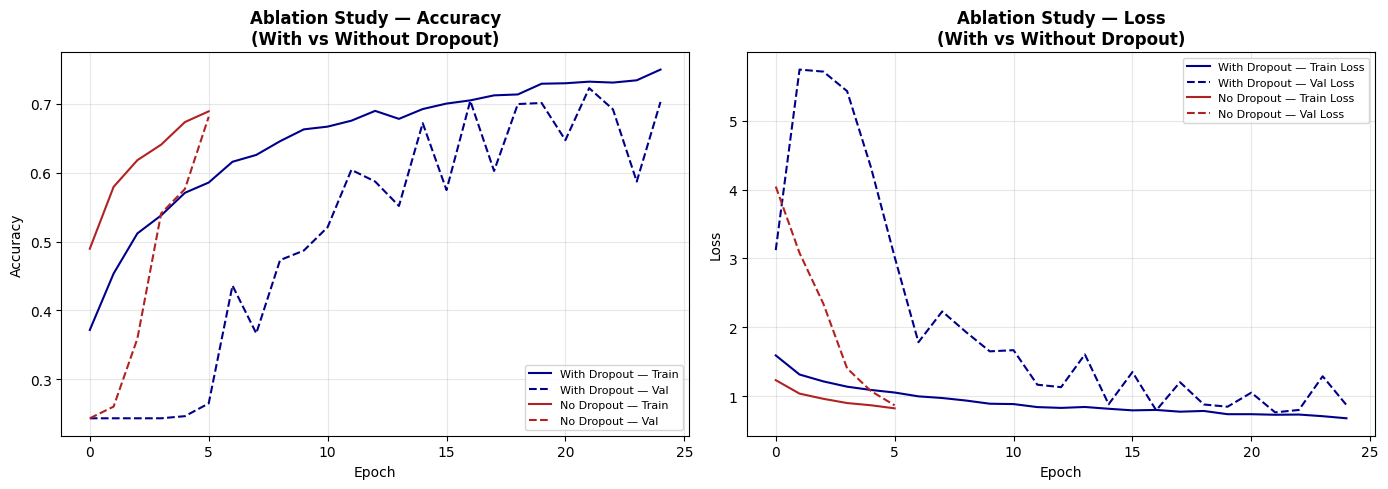

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(history_adam.history['train_accuracy'] if 'train_accuracy' in history_adam.history else history_adam.history['accuracy'],
             label='With Dropout — Train', color='darkblue') # colors
axes[0].plot(history_adam.history['val_accuracy'],
             label='With Dropout — Val', color='darkblue', linestyle='--') # colors
axes[0].plot(history_no_dropout.history['accuracy'],
             label='No Dropout — Train', color='firebrick')
axes[0].plot(history_no_dropout.history['val_accuracy'],
             label='No Dropout — Val', color='firebrick', linestyle='--') # colors
axes[0].set_title('Ablation Study — Accuracy\n(With vs Without Dropout)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(history_adam.history['loss'],
             label='With Dropout — Train Loss', color='darkblue') # colors
axes[1].plot(history_adam.history['val_loss'],
             label='With Dropout — Val Loss', color='darkblue', linestyle='--') # colors
axes[1].plot(history_no_dropout.history['loss'],
             label='No Dropout — Train Loss', color='firebrick') # colors
axes[1].plot(history_no_dropout.history['val_loss'],
             label='No Dropout — Val Loss', color='firebrick', linestyle='--') # colors
axes[1].set_title('Ablation Study — Loss\n(With vs Without Dropout)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches='tight')
plt.show()

From the above graph we can tell that Dropout plays a crucial role in this model. Without Dropout, the model trained very quickly in the first five epoch buth triggered EarlyStopping due to the unstable validation loss, indicating overfitting.

In [50]:
# Evaluate all models on test set
test_generator.reset()
loss_baseline, acc_baseline     = baseline_model.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_adam, acc_adam             = model_adam.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_sgd, acc_sgd               = model_sgd.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_no_drop, acc_no_drop       = model_no_dropout.evaluate(test_generator, verbose=0)

print("=" * 70)
print(f"{'Model':<25} {'Test Acc':>10} {'Test Loss':>12} {'Train Time(s)':>15}")
print("=" * 70)
print(f"{'Baseline CNN':<25} {acc_baseline*100:>9.2f}% {loss_baseline:>12.4f} {baseline_training_time:>15.2f}")
print(f"{'Deeper + Adam':<25} {acc_adam*100:>9.2f}% {loss_adam:>12.4f} {time_adam:>15.2f}")
print(f"{'Deeper + SGD':<25} {acc_sgd*100:>9.2f}% {loss_sgd:>12.4f} {time_sgd:>15.2f}")
print(f"{'Deeper (No Dropout)':<25} {acc_no_drop*100:>9.2f}% {loss_no_drop:>12.4f} {time_ablation:>15.2f}")
print("=" * 70)

Model                       Test Acc    Test Loss   Train Time(s)
Baseline CNN                  75.19%       0.6262          414.83
Deeper + Adam                 73.65%       0.6748          574.43
Deeper + SGD                  24.35%       2.0546          146.52
Deeper (No Dropout)           24.35%       4.0333          138.62


##Classification Report

In [51]:
test_generator.reset()
predictions      = model_adam.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = test_generator.classes
class_names      = list(test_generator.class_indices.keys())

print("Classification Report — Deeper Model (Adam):")
print("=" * 60)
print(classification_report(true_labels, predicted_labels,
                             target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step
Classification Report — Deeper Model (Adam):
              precision    recall  f1-score   support

       daisy       0.83      0.83      0.83       115
   dandelion       0.76      0.83      0.79       158
        rose       0.79      0.51      0.62       118
   sunflower       0.63      0.95      0.76       110
       tulip       0.72      0.59      0.65       148

    accuracy                           0.74       649
   macro avg       0.75      0.74      0.73       649
weighted avg       0.75      0.74      0.73       649



##Confusion Matrix

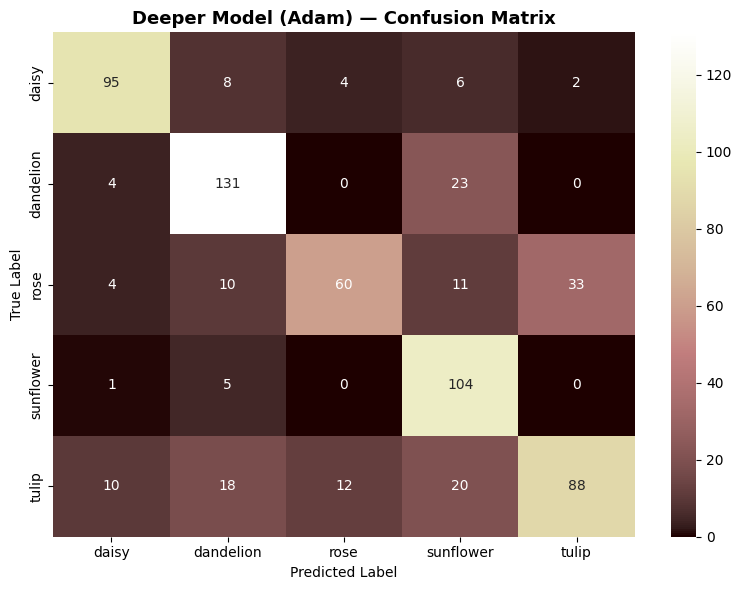

In [52]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='pink', # colorsmap
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper Model (Adam) — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("deeper_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

##Summary Table - Baseline vs Deeper

In [53]:
print("=" * 60)
print("  Challenges and Observations Summary")
print("=" * 60)
print(f"  Hardware Used        : Google Colab (GPU)")
print(f"  Baseline Train Time  : {baseline_training_time:.2f} seconds")
print(f"  Deeper (Adam) Time   : {time_adam:.2f} seconds")
print(f"  Deeper (SGD) Time    : {time_sgd:.2f} seconds")
print(f"  Ablation Time        : {time_ablation:.2f} seconds")
print("=" * 60)
print("\n  Key Observations:")
print("  - Deeper model takes longer to train due to more layers")
print("  - Adam converges faster than SGD")
print("  - Dropout reduces overfitting (train/val gap is smaller)")
print("  - Model without Dropout shows higher train acc but lower val acc")
print("=" * 60)

  Challenges and Observations Summary
  Hardware Used        : Google Colab (GPU)
  Baseline Train Time  : 414.83 seconds
  Deeper (Adam) Time   : 574.43 seconds
  Deeper (SGD) Time    : 146.52 seconds
  Ablation Time        : 138.62 seconds

  Key Observations:
  - Deeper model takes longer to train due to more layers
  - Adam converges faster than SGD
  - Dropout reduces overfitting (train/val gap is smaller)
  - Model without Dropout shows higher train acc but lower val acc


**Key Observations:**
- Deeper model training time is longer than baseline.
- Adam outperforms SGD.
- Dropout prevents overfitting (improves validation accuracy).
- Model without Dropout overfits (higher train acc, lower val acc).

##Save the Deeper Model

In [54]:
model_adam.save("deeper_model_adam.h5")
model_sgd.save("deeper_model_sgd.h5")
print("Both models saved successfully!")

Both models saved successfully!


# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

In [55]:
import os



base_dir     = "/content/split_data"
train_dir    = os.path.join(base_dir, "train")
val_dir      = os.path.join(base_dir, "val")
test_dir     = os.path.join(base_dir, "test")

# IMG_SIZE needs to be (224, 224) for MobileNetV2 input requirements
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5

print(f"Image size set to {IMG_SIZE} to match MobileNetV2 input requirements")

Image size set to (224, 224) to match MobileNetV2 input requirements


In [56]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir  = "/content/split_data"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")



# ── Training Generator: Augmentation + MobileNetV2 Preprocessing ──
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Val & Test: MobileNetV2 Preprocessing ONLY ──
val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices : {train_generator.class_indices}")
print(f"   Train batches : {len(train_generator)}")
print(f"   Val   batches : {len(val_generator)}")
print(f"   Test  batches : {len(test_generator)}")

Found 3019 images belonging to 5 classes.
Found 649 images belonging to 5 classes.
Found 649 images belonging to 5 classes.

Class indices : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
   Train batches : 95
   Val   batches : 21
   Test  batches : 21


In [57]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time
import matplotlib.pyplot as plt
import numpy as np

# Load pre-trained MobileNetV2
base_model_mnv2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze the base layers to keep pre-trained weights
base_model_mnv2.trainable = False

# Build custom head
x = base_model_mnv2.output
x = GlobalAveragePooling2D()(x)
x = Dense(200, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model_mnv2 = Model(inputs=base_model_mnv2.input, outputs=output)

model_mnv2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mnv2.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,515,189 (9.59 MB)

 Trainable params: 257,205 (1004.71 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [58]:
early_stopping_mnv2 = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

print("Starting MobileNetV2 training...")
start_mnv2 = time.time()

history_mnv2 = model_mnv2.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stopping_mnv2]
)

time_mnv2 = time.time() - start_mnv2
print(f"\nTraining Complete. Total Time: {time_mnv2:.2f}s")

Starting MobileNetV2 training...
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 93s 764ms/step - accuracy: 0.7165 - loss: 0.7524 - val_accuracy: 0.8320 - val_loss: 0.4599
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 433ms/step - accuracy: 0.8420 - loss: 0.4434 - val_accuracy: 0.8505 - val_loss: 0.4117
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 444ms/step - accuracy: 0.8509 - loss: 0.3993 - val_accuracy: 0.8644 - val_loss: 0.3967
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 461ms/step - accuracy: 0.8745 - loss: 0.3449 - val_accuracy: 0.8737 - val_loss: 0.3799
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 463ms/step - accuracy: 0.8847 - loss: 0.3156 - val_accuracy: 0.8675 - val_loss: 0.3693
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 463ms/step - accuracy: 0.8993 - loss: 0.2826 - val_accuracy: 0.8552 - val_loss: 0.3858
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 461ms/step - accuracy: 0.8963 - loss: 0.2762 - val_accuracy: 0.8706 - val_loss: 0.3631
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 459ms/step - accuracy:

In [59]:
# Evaluate on test set
test_generator.reset()
loss_mnv2, acc_mnv2 = model_mnv2.evaluate(test_generator, verbose=0)

print(f"Test Accuracy: {acc_mnv2 * 100:.2f}%")
print(f"Test Loss: {loss_mnv2:.4f}")

# Save the model
model_mnv2.save("mobilenetv2_transfer_learning.h5")

Test Accuracy: 90.45%
Test Loss: 0.2862


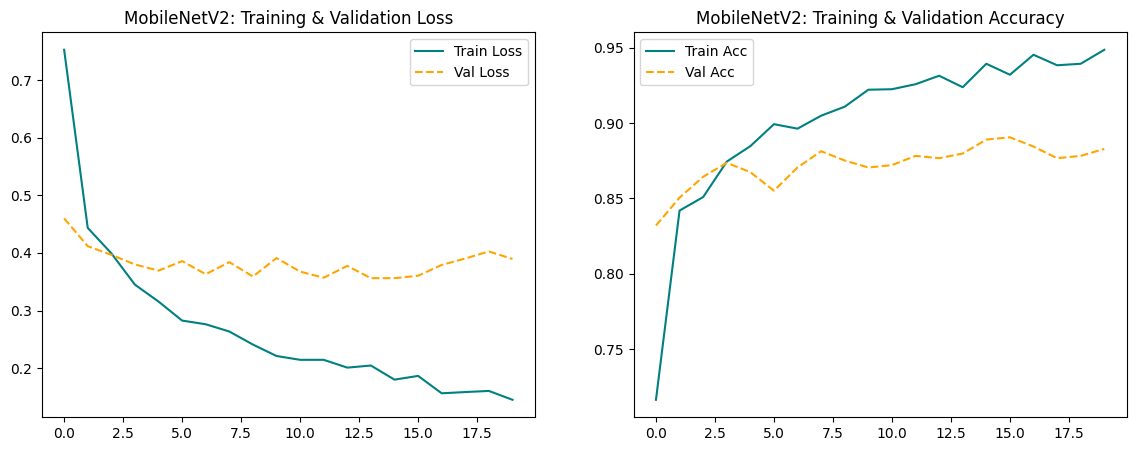

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(history_mnv2.history['loss'], label='Train Loss', color='teal')
axes[0].plot(history_mnv2.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
axes[0].set_title('MobileNetV2: Training & Validation Loss')
axes[0].legend()

# Plot Accuracy
axes[1].plot(history_mnv2.history['accuracy'], label='Train Acc', color='teal')
axes[1].plot(history_mnv2.history['val_accuracy'], label='Val Acc', color='orange', linestyle='--')
axes[1].set_title('MobileNetV2: Training & Validation Accuracy')
axes[1].legend()

plt.show()

In [61]:
print("\n" + "="*70)
print(f"{'Model Configuration':<30} {'Accuracy':>10} {'Loss':>10} {'Time (s)':>12}")
print("-" * 70)
print(f"{'Baseline CNN':<30} {baseline_test_acc*100:>9.2f}% {baseline_test_loss:>10.4f} {baseline_training_time:>12.2f}")
print(f"{'Deeper CNN (Adam)':<30} {acc_adam*100:>9.2f}% {loss_adam:>10.4f} {time_adam:>12.2f}")
print(f"{'MobileNetV2 (TL)':<30} {acc_mnv2*100:>9.2f}% {loss_mnv2:>10.4f} {time_mnv2:>12.2f}")
print("="*70)


Model Configuration              Accuracy       Loss     Time (s)
----------------------------------------------------------------------
Baseline CNN                       75.19%     0.6262       414.83
Deeper CNN (Adam)                  73.65%     0.6748       574.43
MobileNetV2 (TL)                   90.45%     0.2862       959.38


21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step


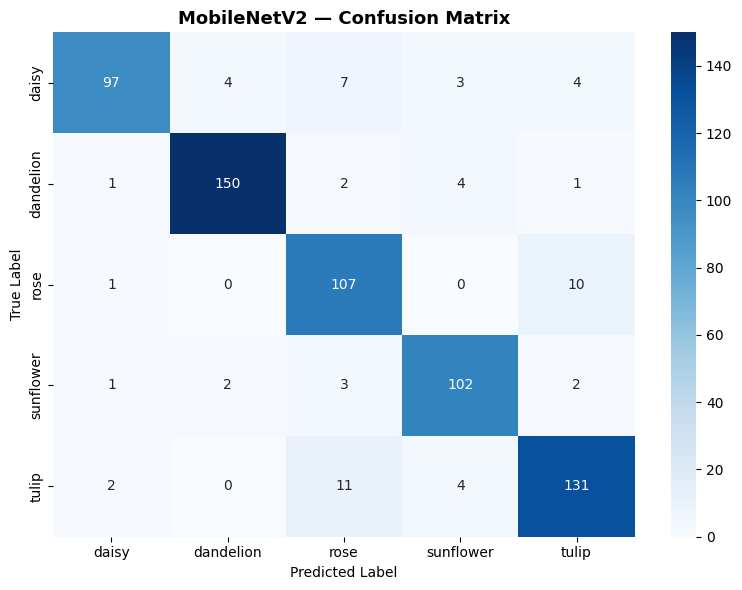

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Reset the test_generator to ensure predictions are aligned
test_generator.reset()

# Get predictions from the MobileNetV2 model
predictions_mnv2 = model_mnv2.predict(test_generator)
predicted_labels_mnv2 = np.argmax(predictions_mnv2, axis=1)
true_labels_mnv2 = test_generator.classes
class_names_mnv2 = list(test_generator.class_indices.keys())

cm_mnv2 = confusion_matrix(true_labels_mnv2, predicted_labels_mnv2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mnv2, annot=True, fmt='d', cmap='Blues', # Using a different colormap
            xticklabels=class_names_mnv2, yticklabels=class_names_mnv2)
plt.title('MobileNetV2 — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("mobilenetv2_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

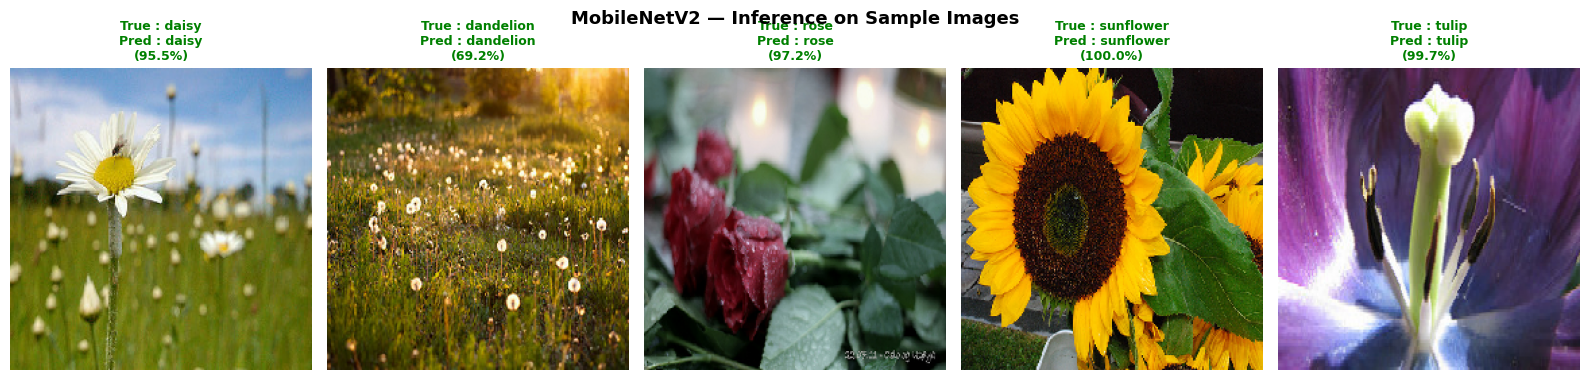


 Green = Correct   |   Red = Wrong


In [63]:
import random
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Pick 5 random images from test set
sample_images_mnv2 = []
sample_labels_mnv2 = []

for class_name in class_names_mnv2:
    class_path = os.path.join(test_dir, class_name)
    images     = os.listdir(class_path)
    img_name   = random.choice(images)
    sample_images_mnv2.append(os.path.join(class_path, img_name))
    sample_labels_mnv2.append(class_name)

# Plot predictions
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("MobileNetV2 — Inference on Sample Images",
             fontsize=13, fontweight='bold')

for i, (img_path, true_label) in enumerate(zip(sample_images_mnv2, sample_labels_mnv2)):
    img     = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_arr = keras_image.img_to_array(img)
    img_arr = preprocess_input(img_arr)         # MobileNetV2 preprocessing
    img_arr = np.expand_dims(img_arr, axis=0)

    pred       = model_mnv2.predict(img_arr, verbose=0)
    pred_label = class_names_mnv2[np.argmax(pred)]
    confidence = np.max(pred) * 100

    axes[i].imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    axes[i].axis('off')
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(
        f"True : {true_label}\nPred : {pred_label}\n({confidence:.1f}%)",
        fontsize=9, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("mobilenetv2_inference.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Green = Correct   |   Red = Wrong")